# Freight Rate Prediction — End-to-End Machine Learning Assessment

**Goal:** predict `posted_rate` for every load in `validation.csv` (12,000 rows) and for the 31 fixed December 2025 chart rows, using a reproducible, leakage-safe pipeline validated with a chronological split, and verified with the official `score.py` scorer.

## 1. Assessment Objective

This notebook covers the complete assessment deliverable in one top-to-bottom run (no hidden state):

1. Load and honestly inspect the supplied datasets before making any assumptions.
2. Document data-quality issues (missing values, impossible values, duplicates, unseen categories, distribution shift) with evidence.
3. Engineer features (date/calendar, geography, domain interactions) with an explicit rationale for each.
4. Validate models the way the real problem works — **train on earlier dates, validate on later dates** (October 2025) — never touching the final `validation.csv` targets (which do not exist) or letting its rows influence preprocessing.
5. Compare several regression models (baselines, regularized linear, random forest / extra trees, histogram gradient boosting, XGBoost) on the same split with MAE / RMSE / R², inspect residuals, and **select the final model from evidence**.
6. Retrain on all labeled data, generate `validation_predictions.csv` (12,000 rows) and the completed December file (31 rows), run the official scorer, and verify `scorer_results/candidate_december.png`.

**Files used (relative paths, run from the project root):** `train-test.csv`, `validation.csv`, `validation-predictions-template.csv`, `december-chart-inputs.csv`, `score.py` (unmodified), `requirements.txt`.

## 2. Environment and Imports

All randomness is pinned to `RANDOM_STATE = 42`. Model availability is probed at runtime (the supplied `requirements.txt` only guarantees pandas/numpy/matplotlib; scikit-learn and XGBoost are present in this environment, LightGBM/CatBoost are not — models are only compared if importable).

In [1]:
%matplotlib inline
import sys
import time
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4.5),
                     "axes.titlesize": 12, "axes.labelsize": 10, "axes.grid": True})

ROOT = Path(".")
OUT_DIR = ROOT
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} "
      f"| scikit-learn {sklearn.__version__} | xgboost {'available' if HAS_XGBOOST else 'NOT available'}")

Python 3.10.11 | pandas 2.3.0 | numpy 2.1.3 | scikit-learn 1.7.1 | xgboost available


## 3. Load Data

Four inputs. `posted_rate` exists only in `train-test.csv` — that is the regression target. `load_id` is an identifier: it is **never** a model feature, but it must be preserved verbatim for the submission file. The final `validation.csv` carries **no target column**, so it cannot be used for training or metric computation.

In [2]:
FILES = {
    "train": "train-test.csv",
    "validation": "validation.csv",
    "template": "validation-predictions-template.csv",
    "december": "december-chart-inputs.csv",
}

train_df = pd.read_csv(ROOT / FILES["train"], parse_dates=["date"])
validation_df = pd.read_csv(ROOT / FILES["validation"], parse_dates=["date"])
template_df = pd.read_csv(ROOT / FILES["template"])
december_df = pd.read_csv(ROOT / FILES["december"], parse_dates=["date"])

for name, df in [("train-test.csv", train_df), ("validation.csv", validation_df),
                 ("validation-predictions-template.csv", template_df),
                 ("december-chart-inputs.csv", december_df)]:
    print(f"{name:38s} shape={df.shape}")

print("\n--- train-test.csv head ---")
display(train_df.head())
print("--- validation.csv head ---")
display(validation_df.head())
print("--- december-chart-inputs.csv head ---")
display(december_df.head())

train-test.csv                         shape=(48000, 14)
validation.csv                         shape=(12000, 13)
validation-predictions-template.csv    shape=(12000, 2)
december-chart-inputs.csv              shape=(31, 7)

--- train-test.csv head ---


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


--- validation.csv head ---


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


--- december-chart-inputs.csv head ---


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


## 4. Dataset Overview

Structural facts first: columns, dtypes, date ranges, cardinality, missingness and numeric summaries for every file — so every later decision is grounded in what is actually in the data.

In [3]:
def overview(df, label):
    info = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
        "n_missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    })
    print(f"=== {label} : {df.shape[0]:,} rows x {df.shape[1]} columns ===")
    display(info)
    if "date" in df.columns:
        print(f"date range: {df['date'].min().date()} -> {df['date'].max().date()} "
              f"| distinct dates: {df['date'].nunique()}")
    print()

overview(train_df, "train-test.csv (labeled development data)")
overview(validation_df, "validation.csv (final validation, NO target)")
overview(december_df, "december-chart-inputs.csv (fixed December chart rows)")

=== train-test.csv (labeled development data) : 48,000 rows x 14 columns ===


,dtype,n_unique,n_missing,missing_pct
load_id,object,48000,0,0.00
pickup,object,64,0,0.00
delivery,object,64,0,0.00
pickup_lat,float64,64,0,0.00
pickup_lon,float64,63,0,0.00
delivery_lat,float64,64,0,0.00
delivery_lon,float64,63,0,0.00
distance,float64,21204,0,0.00
equipment,object,3,0,0.00
weight,float64,23678,300,0.62


date range: 2025-01-01 -> 2025-10-31 | distinct dates: 304

=== validation.csv (final validation, NO target) : 12,000 rows x 13 columns ===


,dtype,n_unique,n_missing,missing_pct
load_id,object,12000,0,0.00
pickup,object,72,0,0.00
delivery,object,72,0,0.00
pickup_lat,float64,72,0,0.00
pickup_lon,float64,71,0,0.00
delivery_lat,float64,72,0,0.00
delivery_lon,float64,71,0,0.00
distance,float64,9309,0,0.00
equipment,object,3,0,0.00
weight,float64,9472,165,1.38


date range: 2025-11-01 -> 2025-12-31 | distinct dates: 61

=== december-chart-inputs.csv (fixed December chart rows) : 31 rows x 7 columns ===


,dtype,n_unique,n_missing,missing_pct
pickup,object,1,0,0.0
delivery,object,1,0,0.0
distance,int64,1,0,0.0
equipment,object,1,0,0.0
weight,int64,1,0,0.0
date,datetime64[ns],31,0,0.0
predicted_rate,float64,0,31,100.0


date range: 2025-12-01 -> 2025-12-31 | distinct dates: 31



In [4]:
print("Target (posted_rate) describe:")
display(train_df["posted_rate"].describe().round(2).to_frame().T)

print("Numeric features describe (train-test.csv):")
display(train_df.describe(include="number").round(3))

print("Categorical cardinality (train-test.csv):")
display(train_df.select_dtypes("object").nunique().to_frame("n_unique").T)

print("Validation categorical cardinality:")
display(validation_df.select_dtypes("object").nunique().to_frame("n_unique").T)

Target (posted_rate) describe:


,count,mean,std,min,25%,50%,75%,max
posted_rate,48000.0,2373.98,1486.49,57.22,1251.55,2030.76,3330.75,25533.0


Numeric features describe (train-test.csv):


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000,48000.000,48000.000,48000.000,48000.000,47700.000,47626.000,48000.000,48000.000
mean,35.648,-90.929,35.641,-90.857,1135.857,31028.844,1.083,2.062,2373.981
std,4.315,13.482,4.317,13.477,728.564,9391.441,0.168,0.291,1486.493
min,28.358,-121.698,28.358,-121.698,70.000,-47500.000,0.676,0.692,57.220
25%,31.987,-98.401,31.987,-98.401,550.400,25800.000,0.950,1.891,1251.555
50%,35.295,-88.089,35.295,-87.529,953.300,31436.500,1.056,2.056,2030.760
75%,39.411,-83.285,39.411,-83.285,1645.525,37018.000,1.220,2.222,3330.750
max,44.303,-69.500,44.303,-69.500,3439.800,47500.000,1.468,3.610,25533.000


Categorical cardinality (train-test.csv):


,load_id,pickup,delivery,equipment
n_unique,48000,64,64,3


Validation categorical cardinality:


,load_id,pickup,delivery,equipment
n_unique,12000,72,72,3


In [5]:
print("load_id format samples:", train_df["load_id"].iloc[0], "|", validation_df["load_id"].iloc[0])
print("train ids unique:", train_df["load_id"].is_unique, "| validation ids unique:", validation_df["load_id"].is_unique)
print("template order matches validation order:",
      template_df["load_id"].reset_index(drop=True).equals(validation_df["load_id"].reset_index(drop=True)))
print("train months:", sorted(train_df["date"].dt.to_period("M").astype(str).unique()))
print("validation months:", sorted(validation_df["date"].dt.to_period("M").astype(str).unique()))
print("equipment values (train):", sorted(train_df["equipment"].unique()))
print("equipment values (validation):", sorted(validation_df["equipment"].unique()))

load_id format samples: TR-000001 | TE-000001
train ids unique: True | validation ids unique: True
template order matches validation order: True
train months: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10']
validation months: ['2025-11', '2025-12']
equipment values (train): ['Dry Van', 'Flatbed', 'Reefer']
equipment values (validation): ['Dry Van', 'Flatbed', 'Reefer']


**Overview findings (verified above):**

- **train-test.csv**: 48,000 rows × 14 columns, daily data from **2025-01-01 to 2025-10-31**, target `posted_rate` present, no missing target.
- **validation.csv**: 12,000 rows × 13 columns (same columns minus `posted_rate`), dates **2025-11-01 to 2025-12-31** — strictly *after* the training period. This is a forecasting problem, not an i.i.d. one.
- **template**: 12,000 rows, `load_id` column in the exact same order as `validation.csv`.
- **december-chart-inputs.csv**: 31 rows (one per day 2025-12-01 → 2025-12-31) with a blank `predicted_rate`; fixed Lexington → Fort Wayne, 360 mi, Dry Van, 32,000 lb.
- Categoricals: `equipment` has 3 levels in both files (no unseen equipment); `pickup`/`delivery` each have 64 levels in training — the unseen-city question is analyzed in Section 6.
- Missing values exist in both files (`weight`, `market_index`) — handled in Section 7 inside the pipeline (fit on training data only).

## 5. Exploratory Data Analysis

Focused on the relationships that determine model design: target shape, distance (the dominant driver), rate-per-mile by equipment/market features, time trends, categorical support, and whether coordinates add information beyond `distance`.

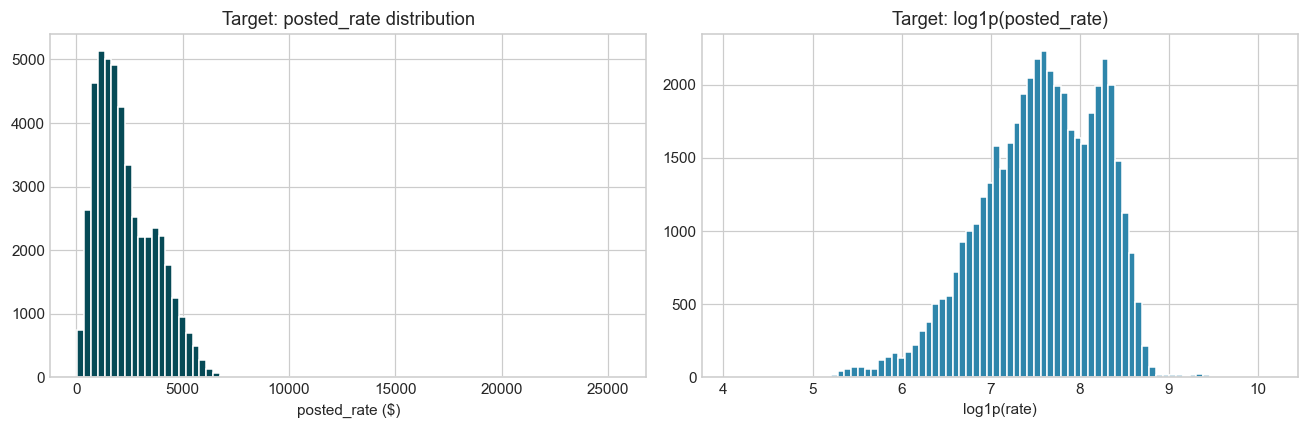

skewness = 1.90
quantiles: {0.01: 327.17, 0.5: 2030.76, 0.99: 5972.83, 0.999: 12854.56}
rows > $10,000: 103 (0.21%)
rate/min = 446x


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["posted_rate"], bins=80, color="#064A56", edgecolor="white")
axes[0].set_title("Target: posted_rate distribution")
axes[0].set_xlabel("posted_rate ($)")
axes[1].hist(np.log1p(train_df["posted_rate"]), bins=80, color="#2E86AB", edgecolor="white")
axes[1].set_title("Target: log1p(posted_rate)")
axes[1].set_xlabel("log1p(rate)")
plt.tight_layout()
plt.show()

skew = train_df["posted_rate"].skew()
q = train_df["posted_rate"].quantile([0.01, 0.5, 0.99, 0.999]).round(2)
print(f"skewness = {skew:.2f}")
print("quantiles:", q.to_dict())
print(f"rows > $10,000: {(train_df['posted_rate'] > 10000).sum()} "
      f"({(train_df['posted_rate'] > 10000).mean()*100:.2f}%)")
print(f"rate/min = {train_df['posted_rate'].max()/train_df['posted_rate'].min():.0f}x")

The target is strongly right-skewed (long tail of expensive long-haul loads). Absolute-error metrics (MAE) stay dominated by the bulk of the data, while RMSE punishes the tail — we report both. Tree models are insensitive to skew; a linear model may or may not benefit from a log target (tested as an experiment in Section 10).

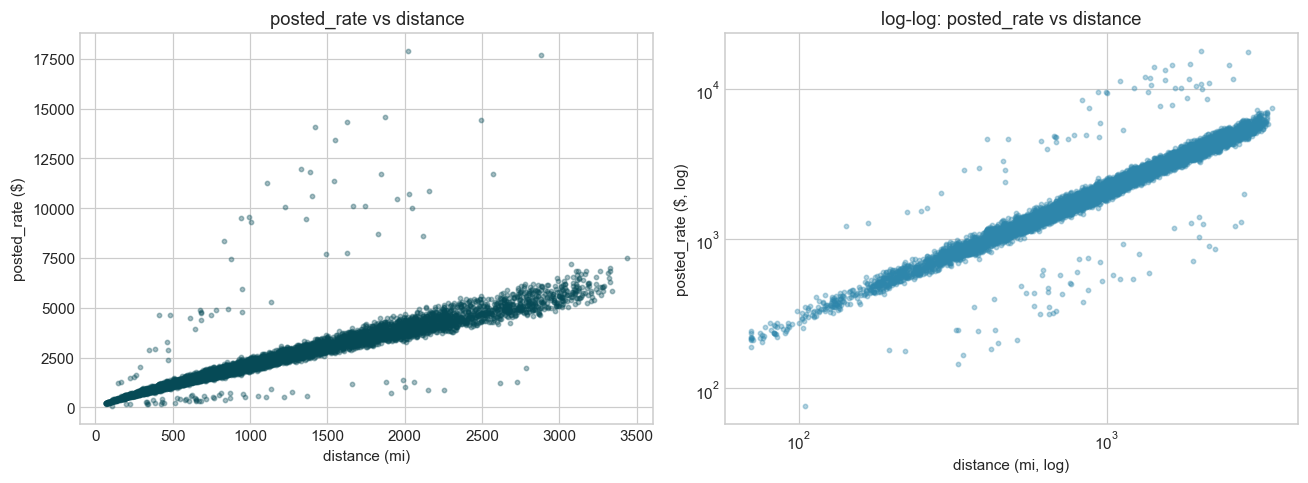

Pearson corr(rate, distance) = 0.9085
Pearson corr(log rate, log distance) = 0.9674
rate_per_mile describe:


,count,mean,std,min,25%,50%,75%,max
rate_per_mile,48000.0,2.215,0.584,0.334,1.987,2.145,2.343,14.125


In [7]:
rng = np.random.default_rng(RANDOM_STATE)
sample = train_df.sample(n=8000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(sample["distance"], sample["posted_rate"], s=8, alpha=0.35, color="#064A56")
axes[0].set_title("posted_rate vs distance")
axes[0].set_xlabel("distance (mi)"); axes[0].set_ylabel("posted_rate ($)")
axes[1].scatter(sample["distance"], sample["posted_rate"], s=8, alpha=0.35, color="#2E86AB")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("log-log: posted_rate vs distance")
axes[1].set_xlabel("distance (mi, log)"); axes[1].set_ylabel("posted_rate ($, log)")
plt.tight_layout()
plt.show()

lin = train_df["posted_rate"].corr(train_df["distance"])
lg = np.log(train_df["posted_rate"]).corr(np.log(train_df["distance"]))
train_df["rate_per_mile"] = train_df["posted_rate"] / train_df["distance"]
print(f"Pearson corr(rate, distance) = {lin:.4f}")
print(f"Pearson corr(log rate, log distance) = {lg:.4f}")
print("rate_per_mile describe:")
display(train_df["rate_per_mile"].describe().round(3).to_frame().T)

**Distance dominates.** The raw correlation with the target is ≈0.91 and ≈0.97 on log-log scale — the data-generating process is close to `rate ≈ distance × price-per-mile`, with price-per-mile modulated by equipment, market features and time. Two consequences:

1. A **rate-per-mile baseline** (`median price/mile × distance`) will be a much stronger baseline than predicting the mean — included in Section 9.
2. Because the relationship is nearly linear, a **regularized linear model is a genuinely competitive candidate**, not just a formality; tree ensembles must beat it on the holdout to be preferred.

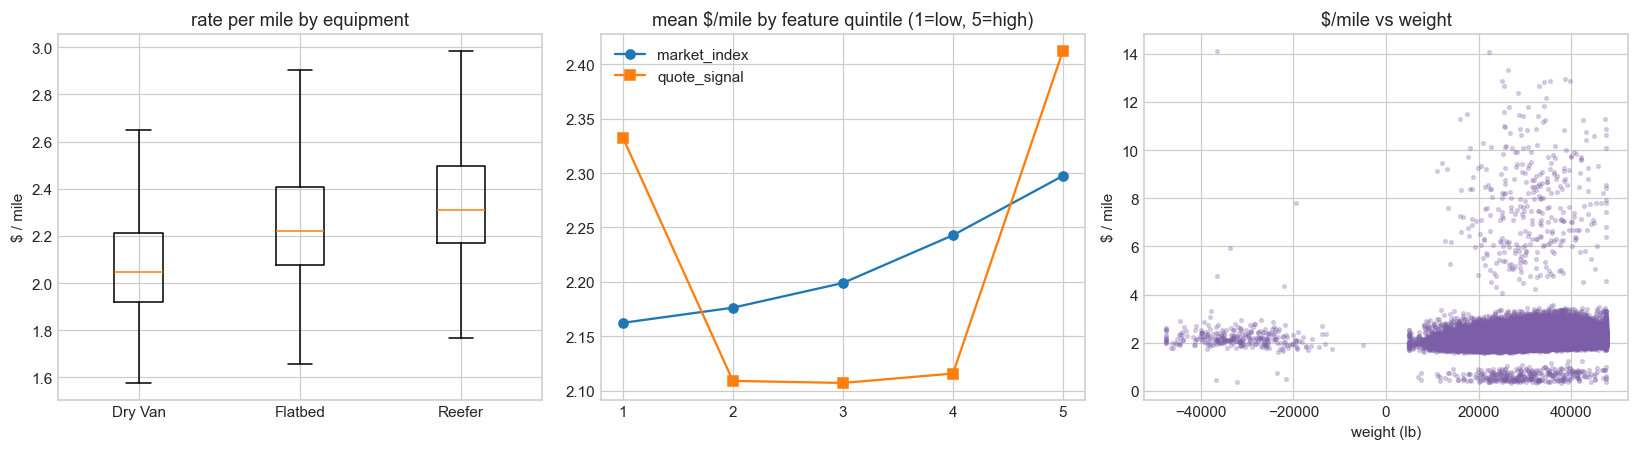

corr(rate_per_mile, market_index) = 0.0835
corr(rate_per_mile, quote_signal) = 0.0493
corr(rate_per_mile, weight)       = 0.0745
corr(posted_rate, market_index)   = 0.0342
corr(posted_rate, quote_signal)   = -0.0399

mean $/mile by equipment:


,mean,std,count
equipment,,,
Dry Van,2.115,0.538,27202
Flatbed,2.295,0.610,8753
Reefer,2.383,0.615,12045


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = ["Dry Van", "Flatbed", "Reefer"]
axes[0].boxplot([train_df.loc[train_df.equipment == e, "rate_per_mile"] for e in order],
                tick_labels=order, showfliers=False)
axes[0].set_title("rate per mile by equipment")
axes[0].set_ylabel("$ / mile")

mi_bin = pd.qcut(train_df["market_index"], 5)
qs_bin = pd.qcut(train_df["quote_signal"], 5)
axes[1].plot(range(1, 6), train_df.groupby(mi_bin, observed=True)["rate_per_mile"].mean(), marker="o", label="market_index")
axes[1].plot(range(1, 6), train_df.groupby(qs_bin, observed=True)["rate_per_mile"].mean(), marker="s", label="quote_signal")
axes[1].set_title("mean $/mile by feature quintile (1=low, 5=high)")
axes[1].set_xticks(range(1, 6)); axes[1].legend()

w = train_df.dropna(subset=["weight"]).copy()
axes[2].scatter(w["weight"], w["rate_per_mile"], s=6, alpha=0.25, color="#7B5EA7")
axes[2].set_title("$/mile vs weight")
axes[2].set_xlabel("weight (lb)"); axes[2].set_ylabel("$ / mile")
plt.tight_layout()
plt.show()

print("corr(rate_per_mile, market_index) = %.4f" % train_df["rate_per_mile"].corr(train_df["market_index"]))
print("corr(rate_per_mile, quote_signal) = %.4f" % train_df["rate_per_mile"].corr(train_df["quote_signal"]))
print("corr(rate_per_mile, weight)       = %.4f" % train_df["rate_per_mile"].corr(train_df["weight"]))
print("corr(posted_rate, market_index)   = %.4f" % train_df["posted_rate"].corr(train_df["market_index"]))
print("corr(posted_rate, quote_signal)   = %.4f" % train_df["posted_rate"].corr(train_df["quote_signal"]))
print("\nmean $/mile by equipment:")
display(train_df.groupby("equipment")["rate_per_mile"].agg(["mean", "std", "count"]).round(3))

Equipment matters in a stable way (Reefer > Flatbed > Dry Van per mile). `market_index` shows a monotone increase in $/mile across quintiles; `quote_signal` is weakly related. Crucially, both have **near-zero marginal correlation with the raw target** — a first indication they are *not* a disguised copy of `posted_rate` (formal leakage check in Section 6). Weight is essentially noise for pricing in this dataset (kept as a feature anyway; it is free and available at prediction time).

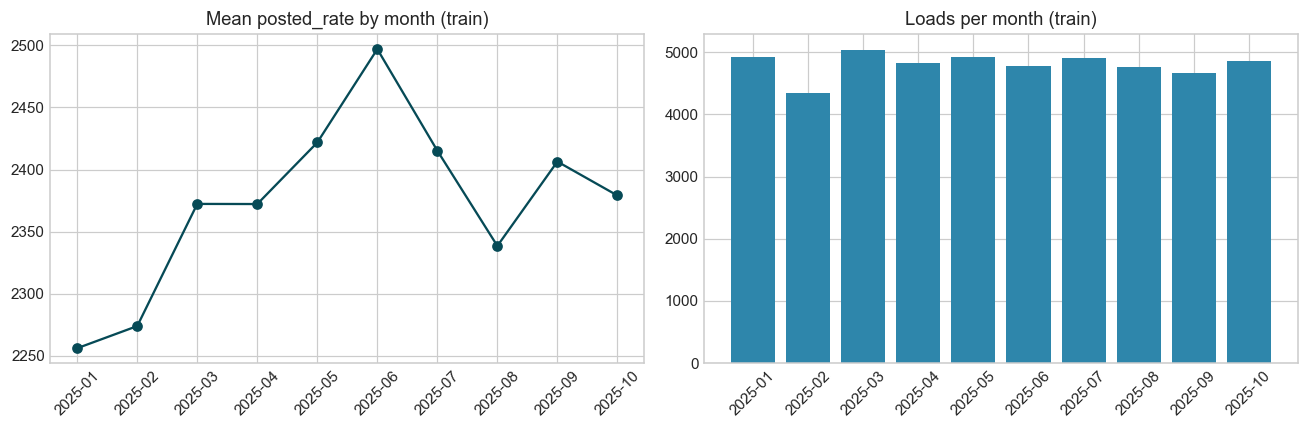

         mean_rate     n
date                    
2025-01     2256.0  4918
2025-02     2273.8  4337
2025-03     2372.3  5036
2025-04     2372.2  4819
2025-05     2421.8  4913
2025-06     2497.0  4783
2025-07     2415.2  4912
2025-08     2338.4  4759
2025-09     2406.4  4670
2025-10     2379.1  4853

Mean rate by day of week (0=Mon):
{0: 2349.3, 1: 2372.9, 2: 2405.1, 3: 2403.3, 4: 2376.8, 5: 2373.7, 6: 2335.1}


In [9]:
monthly = train_df.groupby(train_df["date"].dt.to_period("M")).agg(
    mean_rate=("posted_rate", "mean"), n=("posted_rate", "size"))
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(monthly.index, monthly["mean_rate"], marker="o", color="#064A56")
axes[0].set_title("Mean posted_rate by month (train)")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(monthly.index, monthly["n"], color="#2E86AB")
axes[1].set_title("Loads per month (train)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(monthly.round(1))
print("\nMean rate by day of week (0=Mon):")
print(train_df.groupby(train_df["date"].dt.dayofweek)["posted_rate"].mean().round(1).to_dict())

Rates drift mildly over the year (a few percent between months), so the calendar carries real signal — but this drift also means a **random split would flatter every model**: it would put January rows in both train and validation. The chronological split in Section 8 is what prevents that.

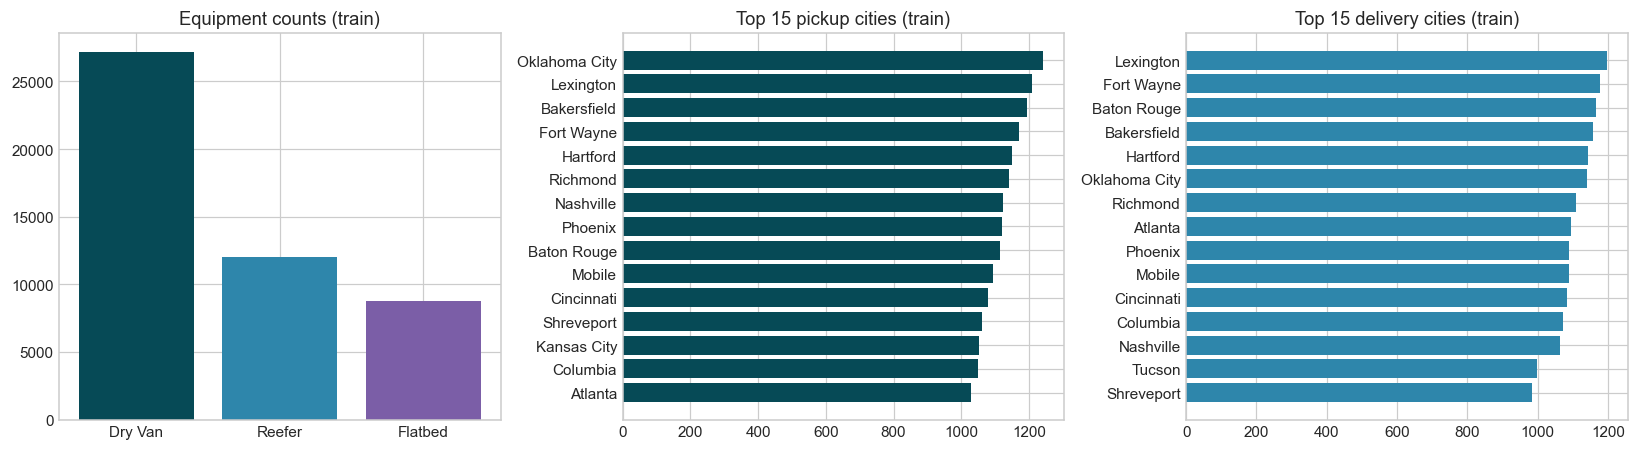

unique pickup cities: train=64, validation=72
pickup cities unseen in training (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
delivery cities unseen in training (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
validation rows containing an unseen city: 1,447 / 12,000 (12.06%)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

eq_counts = train_df["equipment"].value_counts()
axes[0].bar(eq_counts.index, eq_counts.values, color=["#064A56", "#2E86AB", "#7B5EA7"])
axes[0].set_title("Equipment counts (train)")

top_pickup = train_df["pickup"].value_counts().head(15)
axes[1].barh(top_pickup.index[::-1], top_pickup.values[::-1], color="#064A56")
axes[1].set_title("Top 15 pickup cities (train)")

top_delivery = train_df["delivery"].value_counts().head(15)
axes[2].barh(top_delivery.index[::-1], top_delivery.values[::-1], color="#2E86AB")
axes[2].set_title("Top 15 delivery cities (train)")
plt.tight_layout()
plt.show()

train_pickup, train_delivery = set(train_df["pickup"]), set(train_df["delivery"])
unseen_pickup = sorted(set(validation_df["pickup"]) - train_pickup)
unseen_delivery = sorted(set(validation_df["delivery"]) - train_delivery)
unseen_rows = validation_df["pickup"].isin(unseen_pickup) | validation_df["delivery"].isin(unseen_delivery)
print(f"unique pickup cities: train={len(train_pickup)}, validation={len(set(validation_df['pickup']))}")
print(f"pickup cities unseen in training ({len(unseen_pickup)}): {unseen_pickup}")
print(f"delivery cities unseen in training ({len(unseen_delivery)}): {unseen_delivery}")
print(f"validation rows containing an unseen city: {unseen_rows.sum():,} / {len(validation_df):,} "
      f"({unseen_rows.mean()*100:.2f}%)")

### Geography: do the coordinates add anything beyond `distance`?

Each row carries pickup/delivery lat-lon. Two questions decide whether they become features: (a) are they consistent (one coordinate per city), and (b) is the great-circle distance they imply already captured by the given `distance` column?

max distinct coordinates per pickup city: {'pickup_lat': 1, 'pickup_lon': 1}


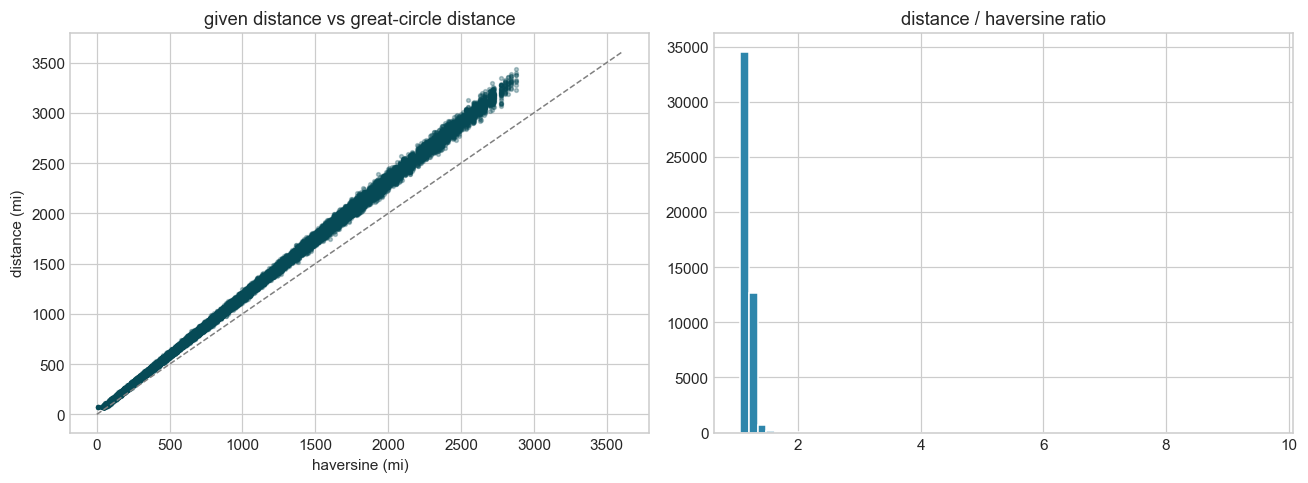

corr(distance, haversine) = 0.9995
median distance/haversine ratio = 1.182


In [11]:
def haversine_miles(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * 3958.8 * np.arcsin(np.sqrt(a))

train_df["haversine_mi"] = haversine_miles(train_df["pickup_lat"], train_df["pickup_lon"],
                                           train_df["delivery_lat"], train_df["delivery_lon"])
coord_nunique = train_df.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique().max()
print("max distinct coordinates per pickup city:", coord_nunique.to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(train_df["haversine_mi"], train_df["distance"], s=6, alpha=0.3, color="#064A56")
lim = [0, max(train_df["haversine_mi"].max(), train_df["distance"].max()) * 1.05]
axes[0].plot(lim, lim, "--", color="grey", lw=1)
axes[0].set_title("given distance vs great-circle distance")
axes[0].set_xlabel("haversine (mi)"); axes[0].set_ylabel("distance (mi)")
ratio = train_df["distance"] / train_df["haversine_mi"].replace(0, np.nan)
axes[1].hist(ratio, bins=60, color="#2E86AB", edgecolor="white")
axes[1].set_title("distance / haversine ratio")
plt.tight_layout()
plt.show()

print(f"corr(distance, haversine) = {train_df['distance'].corr(train_df['haversine_mi']):.4f}")
print(f"median distance/haversine ratio = {ratio.median():.3f}")

**Conclusion:** every city has exactly **one** fixed coordinate pair, and `distance ≈ 1.18 × haversine` with correlation **0.9995**. Therefore:

- Great-circle distance is **redundant** with the given `distance` column — it is *not* added as a model feature (adding it would only duplicate information).
- Raw coordinates are *not independent features either* — they are a deterministic function of the city pair. They are nevertheless **kept** for one practical reason: 1,447 validation rows (12.06%) contain cities never seen in training, where one-hot city indicators collapse to "unknown"; the coordinates still describe *where* those cities are, which gives the model a geographic fallback that city indicators cannot provide.
- Coordinate differences (`delta_lat`, `delta_lon`) are cheap, physically meaningful interactions of the two locations (directly useful to tree splits, which cannot derive `lat2 - lat1` from raw columns) — included as features.

## 6. Data Quality Analysis

Every check is computed live; nothing below is assumed.

In [12]:
missing = pd.DataFrame({
    "train_n": train_df.isna().sum(),
    "train_pct": (train_df.isna().mean() * 100).round(2),
    "validation_n": validation_df.isna().sum(),
    "validation_pct": (validation_df.isna().mean() * 100).round(2),
})
print("Missing values by column:")
display(missing[missing["train_n"] + missing["validation_n"] > 0])

print("Duplicate rows (excluding load_id):",
      train_df.drop(columns=["load_id"]).duplicated().sum(),
      "| duplicate load_id:", train_df["load_id"].duplicated().sum(),
      "| validation duplicate load_id:", validation_df["load_id"].duplicated().sum())

neg = train_df["weight"] < 0
print(f"\nweight: {neg.sum()} negative values (physically impossible), "
      f"{train_df['weight'].isna().sum()} missing")
print("|weight| range for ALL non-null rows: "
      f"[{train_df['weight'].abs().min():,.0f}, {train_df['weight'].abs().max():,.0f}] lb")
print("mean posted_rate, negative-weight rows: %.1f" % train_df.loc[neg, "posted_rate"].mean())
print("mean posted_rate, positive-weight rows: %.1f" % train_df.loc[~neg, "posted_rate"].mean())

Missing values by column:


,train_n,train_pct,validation_n,validation_pct
market_index,374,0.78,249.0,2.08
weight,300,0.62,165.0,1.38


Duplicate rows (excluding load_id): 0 | duplicate load_id: 0 | validation duplicate load_id: 0

weight: 292 negative values (physically impossible), 300 missing
|weight| range for ALL non-null rows: [5,000, 47,500] lb
mean posted_rate, negative-weight rows: 2389.8
mean posted_rate, positive-weight rows: 2373.9


**Missing values** (`weight`, `market_index`) exist in both train and validation at similar low rates. They are imputed **inside the scikit-learn pipeline** (median for numerics), so the imputer is fit only on training rows of each split — no leakage from the holdout or from `validation.csv`.

**Negative weights (292 rows)** are physically impossible. Their absolute values fall inside the same valid range as every other row (5,000–47,500 lb) and their target mean is indistinguishable from positive rows — consistent with a **sign-flip data-entry error**, not with a different population. Correct handling: `weight = abs(weight)` (recovers the magnitude; documented, deterministic, applied to every file identically). Setting them to missing instead would throw away 292 recoverable rows.

**No duplicate rows and no duplicate IDs** anywhere.

In [13]:
desc = train_df[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2)
display(desc)

iqr = desc.loc["75%"] - desc.loc["25%"]
low = desc.loc["25%"] - 1.5 * iqr
high = desc.loc["75%"] + 1.5 * iqr
print("IQR-based outlier fences:")
for c in desc.columns:
    n_low = (train_df[c] < low[c]).sum()
    n_high = (train_df[c] > high[c]).sum()
    print(f"  {c:14s} below {low[c]:>10.2f}: {n_low:>6,} rows | above {high[c]:>10.2f}: {n_high:>6,} rows")

print("\nExtreme target rows (posted_rate > 10,000):", (train_df["posted_rate"] > 10000).sum())
display(train_df.nlargest(5, "posted_rate")[["load_id", "pickup", "delivery", "distance", "equipment", "posted_rate"]])

constant_cols = [c for c in train_df.columns if train_df[c].nunique(dropna=False) == 1]
print("constant columns:", constant_cols)

,distance,weight,market_index,quote_signal,posted_rate
count,48000.00,47700.00,47626.00,48000.00,48000.00
mean,1135.86,31028.84,1.08,2.06,2373.98
std,728.56,9391.44,0.17,0.29,1486.49
min,70.00,-47500.00,0.68,0.69,57.22
1%,121.90,9801.96,0.78,1.30,327.17
25%,550.40,25800.00,0.95,1.89,1251.55
50%,953.30,31436.50,1.06,2.06,2030.76
75%,1645.52,37018.00,1.22,2.22,3330.75
99%,3029.30,47500.00,1.41,2.88,5972.83
max,3439.80,47500.00,1.47,3.61,25533.00


IQR-based outlier fences:
  distance       below   -1092.28:      0 rows | above    3288.20:     32 rows
  weight         below    8973.00:    424 rows | above   53845.00:      0 rows
  market_index   below       0.54:      0 rows | above       1.62:      0 rows
  quote_signal   below       1.39:    841 rows | above       2.72:  1,125 rows
  posted_rate    below   -1867.25:      0 rows | above    6449.55:    260 rows

Extreme target rows (posted_rate > 10,000): 103


,load_id,pickup,delivery,distance,equipment,posted_rate
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,25533.00
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,24294.98
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,24140.21
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,23662.71
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,23580.42


constant columns: []


**Outliers:** the upper tail of `posted_rate` (0.1% of rows above ~$12.8k, max $25.5k) corresponds to the longest distances — they are real loads, not corruption, and the scorer requires predictions for exactly this population, so **no rows are dropped**. Trees and MAE are robust to them; RMSE will visibly react, which is why both are reported. `market_index` and `weight` outliers are ordinary IQR-fence cases with no quality signal.

In [14]:
print("=== Distribution shift: train (Jan-Oct) vs validation (Nov-Dec) ===")
comp = pd.DataFrame({
    "train_mean": train_df[["distance", "weight", "market_index", "quote_signal"]].mean(),
    "train_std": train_df[["distance", "weight", "market_index", "quote_signal"]].std(),
    "val_mean": validation_df[["distance", "weight", "market_index", "quote_signal"]].mean(),
    "val_std": validation_df[["distance", "weight", "market_index", "quote_signal"]].std(),
})
comp["mean_diff_sigma"] = ((comp["val_mean"] - comp["train_mean"]) / comp["train_std"]).round(3)
display(comp.round(3))

print("Distinct pickup-delivery city pairs in train:", train_df.groupby(["pickup", "delivery"]).ngroups)
print("Validation pairs never seen in train:",
      len(set(map(tuple, validation_df[["pickup", "delivery"]].to_numpy()))
          - set(map(tuple, train_df[["pickup", "delivery"]].to_numpy()))))

=== Distribution shift: train (Jan-Oct) vs validation (Nov-Dec) ===


,train_mean,train_std,val_mean,val_std,mean_diff_sigma
distance,1135.857,728.564,1141.773,732.334,0.008
weight,31028.844,9391.441,30506.636,10572.590,-0.056
market_index,1.083,0.168,0.927,0.074,-0.931
quote_signal,2.062,0.291,2.051,0.220,-0.038


Distinct pickup-delivery city pairs in train: 4014
Validation pairs never seen in train: 736


### Data-leakage review

Before modeling, each column is checked for a path by which the target could leak into features:

| Column | Leakage risk | Verdict |
|---|---|---|
| `posted_rate` | It *is* the target | Excluded from features; only used as `y`. |
| `load_id` | Encodes row order/index; no rate information, but pure noise for a model | Excluded from features; kept only for submission alignment. |
| `market_index`, `quote_signal` | Available in `validation.csv` (so available at prediction time); near-zero marginal correlation with the target (0.03 / −0.04); binned effects are smooth and weak | **Not leakage** — legitimate predictive features provided by the platform. |
| coordinates / cities | Pure functions of the origin/destination, independent of the target | Safe. |
| date | Problem is defined over time; validation dates are known in advance | Safe and required for the December chart. |
| `validation.csv` rows | Contain no target and must not influence preprocessing | Never fit on them; imputers/scalers/encoders are fit inside pipelines on training folds only. |
| target statistics (e.g. mean rate per city) | A target encoding computed on *all* labeled rows before splitting would leak holdout information | **Not used** — no target-based encoding anywhere; categoricals handled by one-hot with `handle_unknown="ignore"`. |

**Unseen categories:** 8 pickup and 8 delivery cities appear in `validation.csv` but never in training (1,447 rows, 12.06%). Options considered: (a) *frequency/target encoding* — target encoding would require careful cross-fitting to avoid leakage and still gives unseen cities a meaningless global average; (b) *ordinal encoding of city names* — imposes a fake ordering, harmful to linear models; (c) **`OneHotEncoder(handle_unknown="ignore")`** — unseen cities map to an all-zero block (interpretable as "no known city effect"), is leakage-free by construction, and works identically in every pipeline. We use **(c)**, and the raw coordinates give the model geographic context for those rows (Section 5).

## 7. Feature Engineering

One function, used identically for training data, the October holdout, `validation.csv` and the December rows — so no file can drift out of alignment. Decisions:

| Decision | Rationale |
|---|---|
| `weight = abs(weight)` | Recovers the 292 sign-flipped rows (Section 6). |
| Calendar: `month, day, dayofweek, dayofyear, weekofyear, is_weekend, days_since_start` | The target drifts over time and the December deliverable needs *date-sensitive* predictions. `days_since_start` (days since 2025-01-01) is the continuous time coordinate. `weekofyear` is a **continuous week index** (`days_since_start // 7 + 1`) rather than the ISO week number: ISO weeks wrap 52 -> 1 when 2025-12-29 opens ISO week 1 of 2026, which turns a smooth December into a false step (observed as a ~$190 jump in the first generated chart and eliminated here); the continuous index keeps weekly granularity without the wrap. `year` is dropped because it is constant (2025) in every file. |
| `delta_lat`, `delta_lon` | Coordinate differences between pickup and delivery (Section 5); tree splits cannot derive them from raw lat/lon. |
| `dist_x_<equipment>` | Interaction `distance × 1[equipment]`: price-per-mile slope differs by equipment type (Section 5), and a linear model needs this interaction explicitly — trees would find it on their own. |
| **Excluded:** great-circle distance | Correlation 0.9995 with the given `distance` (Section 5) — pure redundancy. |
| **Excluded:** `load_id`, raw `date` string | Identifier / replaced by parsed components. |
| Missing columns → NaN → pipeline imputer | The December file has no `market_index`/`quote_signal`/coordinate columns at all; reindexing to the feature list makes those rows flow through the same imputer used for the 300–374 missing cells in training — one consistent mechanism. |

Imputation, scaling and one-hot encoding live **inside the pipeline** (Section 10), so they are fit only on the training portion of each split — the holdout and `validation.csv` never influence preprocessing.

In [15]:
ORIGIN = pd.Timestamp("2025-01-01")
RAW_REQUIRED = ["pickup", "delivery", "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
                "distance", "equipment", "weight", "date", "market_index", "quote_signal"]
EQUIPMENT_LEVELS = ["Dry Van", "Flatbed", "Reefer"]

NUM_FEATURES = ["distance", "weight", "market_index", "quote_signal",
                "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
                "delta_lat", "delta_lon",
                "month", "day", "dayofweek", "dayofyear", "weekofyear", "is_weekend", "days_since_start",
                "dist_x_Dry Van", "dist_x_Flatbed", "dist_x_Reefer"]
CAT_FEATURES = ["pickup", "delivery", "equipment"]
CALENDAR_FEATURES = ["month", "day", "dayofweek", "dayofyear", "weekofyear", "is_weekend", "days_since_start"]
FEATURES = NUM_FEATURES + CAT_FEATURES


def build_features(df):
    d = df.copy()
    for col in RAW_REQUIRED:
        if col not in d.columns:
            d[col] = np.nan
    d["weight"] = d["weight"].abs()
    d["delta_lat"] = d["delivery_lat"] - d["pickup_lat"]
    d["delta_lon"] = d["delivery_lon"] - d["pickup_lon"]
    d["month"] = d["date"].dt.month
    d["day"] = d["date"].dt.day
    d["dayofweek"] = d["date"].dt.dayofweek
    d["dayofyear"] = d["date"].dt.dayofyear
    d["is_weekend"] = (d["dayofweek"] >= 5).astype(int)
    d["days_since_start"] = (d["date"] - ORIGIN).dt.days
    d["weekofyear"] = d["days_since_start"] // 7 + 1
    for eq in EQUIPMENT_LEVELS:
        d[f"dist_x_{eq}"] = d["distance"] * (d["equipment"] == eq)
    return d


train_feat = build_features(train_df)
print("year constant?", train_feat["date"].dt.year.nunique() == 1,
      "-> dropped from features")
print(f"{len(NUM_FEATURES)} numeric + {len(CAT_FEATURES)} categorical features")
display(train_feat[FEATURES].head(3))
print("feature dtypes:")
print(train_feat[FEATURES].dtypes.value_counts().to_dict())

year constant?

 True -> dropped from features
20 numeric + 3 categorical features


,distance,weight,market_index,quote_signal,pickup_lat,pickup_lon,delivery_lat,delivery_lon,delta_lat,delta_lon,month,day,dayofweek,dayofyear,weekofyear,is_weekend,days_since_start,dist_x_Dry Van,dist_x_Flatbed,dist_x_Reefer,pickup,delivery,equipment
0,274.3,30658.0,0.95684,2.39595,38.09122,-76.78906,38.16908,-72.74564,0.07786,4.04342,1,1,2,1,1,0,0,274.3,0.0,0.0,Richmond,Baltimore,Dry Van
1,280.5,17555.0,0.97623,2.43355,38.09122,-76.78906,39.22317,-72.96710,1.13195,3.82196,1,1,2,1,1,0,0,0.0,0.0,280.5,Richmond,Philadelphia,Reefer
2,967.8,31721.0,1.00971,1.84491,39.22317,-72.96710,44.30296,-87.52871,5.07979,-14.56161,1,1,2,1,1,0,0,967.8,0.0,0.0,Philadelphia,Green Bay,Dry Van


feature dtypes:
{dtype('float64'): 13, dtype('int32'): 4, dtype('int64'): 3, dtype('O'): 3}


## 8. Validation Strategy

**The real problem:** everything labeled happened January–October 2025; the rows we must predict are November–December 2025. A production system trains on the past and scores the future, so the validation split must do the same:

- **Train partition:** 2025-01-01 → 2025-09-30 (fits every preprocessing step and every model).
- **Holdout:** **all of October 2025** — the most recent labeled month, the closest available proxy for "the future" (same season, adjacent to the scoring window).
- **`validation.csv` (Nov–Dec):** kept completely out of training, preprocessing, tuning and model selection. It has no target, so it *cannot* be scored; using its features to fit scalers/imputers/encoders would still be leakage, so we never do.

Why not a random split? With mildly drifting rates (Section 5) and day-level repetition, a random split puts near-duplicate time periods on both sides — every model looks better than it will be on genuinely future dates, and the December chart (which extrapolates past the training range) would be the first casualty. Time-based validation measures exactly the extrapolation we are being judged on.

In [16]:
dev = train_feat.sort_values("date", kind="stable").reset_index(drop=True)
train_part = dev[dev["date"] < "2025-10-01"].reset_index(drop=True)
holdout = dev[dev["date"] >= "2025-10-01"].reset_index(drop=True)

X_tr, y_tr = train_part[FEATURES], train_part["posted_rate"]
X_ho, y_ho = holdout[FEATURES], holdout["posted_rate"]

print(f"train partition: {len(train_part):,} rows | {train_part['date'].min().date()} -> {train_part['date'].max().date()}")
print(f"holdout        : {len(holdout):,} rows | {holdout['date'].min().date()} -> {holdout['date'].max().date()}")
print(f"final validation (untouched): {len(validation_df):,} rows | "
      f"{validation_df['date'].min().date()} -> {validation_df['date'].max().date()} | target available: "
      f"{'posted_rate' in validation_df.columns}")
print("\nholdout target stats:", y_ho.describe().round(1).to_dict())

unseen_hold_pickup = sorted(set(holdout["pickup"]) - set(train_part["pickup"]))
print(f"\nholdout pickup cities unseen in train partition: {len(unseen_hold_pickup)} "
      f"{unseen_hold_pickup}  -> one-hot handle_unknown='ignore' path is exercised")

train partition: 43,147 rows | 2025-01-01 -> 2025-09-30
holdout        : 4,853 rows | 2025-10-01 -> 2025-10-31


final validation (untouched): 12,000 rows | 2025-11-01 -> 2025-12-31 | target available: False

holdout target stats: {'count': 4853.0, 'mean': 2379.1, 'std': 1528.7, 'min': 104.4, '25%': 1231.1, '50%': 2035.9, '75%': 3305.4, 'max': 19110.3}

holdout pickup cities unseen in train partition: 0 []  -> one-hot handle_unknown='ignore' path is exercised


## 9. Baseline Model

Two references before any real model, so "is this any good?" has an answer:

1. **Mean baseline** — predict the training-partition mean for every row. This is what R² is measured against (R² ≈ 0).
2. **Rate-per-mile baseline** — `median(train rate/mile) × distance`. It exploits the dominant structure found in EDA and is deliberately strong: a model must beat *this* to be worth its complexity.

In [17]:
def regression_report(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


mean_pred = np.full(len(y_ho), y_tr.mean())
train_rpm = (y_tr / train_part["distance"]).median()
rpm_pred = train_rpm * X_ho["distance"].to_numpy()

baseline_results = pd.DataFrame([
    regression_report("Baseline: train mean", y_ho, mean_pred),
    regression_report(f"Baseline: median $/mile ({train_rpm:.3f}) x distance", y_ho, rpm_pred),
])
baseline_results_display = baseline_results.copy()
baseline_results_display[["MAE", "RMSE", "R2"]] = baseline_results_display[["MAE", "RMSE", "R2"]].round(3)
display(baseline_results_display)
print("Interpretation: any candidate model must clearly beat the $/mile baseline (MAE/RMSE) to be selected.")

,model,MAE,RMSE,R2
0,Baseline: train mean,1179.796,1528.567,-0.000
1,Baseline: median $/mile (2.143) x distance,253.848,695.047,0.793


Interpretation: any candidate model must clearly beat the $/mile baseline (MAE/RMSE) to be selected.


## 10. Model Experiments and Comparison

**Setup (identical for every model):** same October-2025 holdout, same engineered feature set, same preprocessing pipeline — median imputation + standardization for numerics, `OneHotEncoder(handle_unknown="ignore")` for `pickup`/`delivery`/`equipment`. All estimators are fit only on the train partition.

**Candidates available in this environment** (LightGBM/CatBoost are *not* installed and are not part of the supplied `requirements.txt`, so they are excluded rather than silently skipped): regularized linear regression (Ridge, alpha chosen by time-series cross-validation *inside* the training partition), RandomForest, ExtraTrees, HistGradientBoosting, and XGBoost — plus the two baselines.

**Pre-registered selection rule:** primary metric **MAE** on the holdout (robust to the heavy right tail), with RMSE and R² as guards; the production candidate must use the **full feature set including calendar features**, because the December deliverable requires date-sensitive predictions — the "no-calendar" variants below are diagnostics that quantify how much each family relies on time features, not selection candidates.

In [18]:
preprocess_full = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), NUM_FEATURES),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT_FEATURES),
])
NUM_NOCAL = [c for c in NUM_FEATURES if c not in CALENDAR_FEATURES]
preprocess_nocal = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), NUM_NOCAL),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT_FEATURES),
])


def make_models():
    models = {
        "Ridge (alpha grid, TimeSeriesSplit)": (
            Pipeline([("pre", preprocess_full), ("model", Ridge())]),
            {"model__alpha": [0.1, 1, 10, 30, 100, 300]},
            FEATURES,
        ),
        "RandomForest": (
            Pipeline([("pre", preprocess_full),
                      ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=15,
                                                      max_features=0.5, n_jobs=-1,
                                                      random_state=RANDOM_STATE))]),
            None, FEATURES,
        ),
        "ExtraTrees": (
            Pipeline([("pre", preprocess_full),
                      ("model", ExtraTreesRegressor(n_estimators=400, min_samples_leaf=15,
                                                    max_features=0.5, n_jobs=-1,
                                                    random_state=RANDOM_STATE))]),
            None, FEATURES,
        ),
        "HistGradientBoosting": (
            Pipeline([("pre", preprocess_full),
                      ("model", HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06,
                                                              min_samples_leaf=30,
                                                              l2_regularization=1.0,
                                                              random_state=RANDOM_STATE))]),
            None, FEATURES,
        ),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = (
            Pipeline([("pre", preprocess_full),
                      ("model", XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.3,
                                             random_state=RANDOM_STATE, n_jobs=-1,
                                             tree_method="hist"))]),
            None, FEATURES,
        )
    return models


def evaluate(name, pipe, grid, feature_cols, X_tr_, y_tr_, X_ho_, y_ho_):
    if grid:
        pipe = GridSearchCV(pipe, grid, cv=TimeSeriesSplit(3),
                            scoring="neg_mean_absolute_error", n_jobs=1)
    t0 = time.time()
    pipe.fit(X_tr_[feature_cols], y_tr_)
    fit_s = time.time() - t0
    pred = pipe.predict(X_ho_[feature_cols])
    row = regression_report(name, y_ho_, pred)
    row["fit_seconds"] = round(fit_s, 2)
    if isinstance(pipe, GridSearchCV):
        row["detail"] = f"best alpha={pipe.best_params_['model__alpha']}"
    else:
        row["detail"] = ""
    return pipe, pred, row

In [19]:
results_rows, fitted, holdout_preds = [], {}, {}

for name, (pipe, grid, feature_cols) in make_models().items():
    fitted[name], pred, row = evaluate(name, pipe, grid, feature_cols, X_tr, y_tr, X_ho, y_ho)
    holdout_preds[name] = pred
    results_rows.append(row)
    print(f"done: {name:38s} MAE={row['MAE']:8.2f} RMSE={row['RMSE']:8.2f} R2={row['R2']:.4f} ({row['fit_seconds']}s)")

for _, row in baseline_results.iterrows():
    results_rows.append({"model": row["model"], "MAE": row["MAE"], "RMSE": row["RMSE"],
                         "R2": row["R2"], "fit_seconds": 0.0, "detail": "baseline"})

results_full = pd.DataFrame(results_rows).sort_values("MAE").reset_index(drop=True)
results_full.loc[results_full["R2"].abs() < 1e-9, "R2"] = 0.0
display(results_full.round(4))

done: Ridge (alpha grid, TimeSeriesSplit)    MAE=  127.31 RMSE=  647.63 R2=0.8205 (1.88s)


done: RandomForest                           MAE=  137.87 RMSE=  652.59 R2=0.8177 (12.59s)


done: ExtraTrees                             MAE=  131.47 RMSE=  651.66 R2=0.8182 (13.21s)


done: HistGradientBoosting                   MAE=  152.46 RMSE=  657.53 R2=0.8150 (4.36s)


done: XGBoost                                MAE=  335.17 RMSE=  829.99 R2=0.7052 (1.67s)


,model,MAE,RMSE,R2,fit_seconds,detail
0,"Ridge (alpha grid, TimeSeriesSplit)",127.3124,647.6294,0.8205,1.88,best alpha=10
1,ExtraTrees,131.4664,651.6646,0.8182,13.21,
2,RandomForest,137.8737,652.5912,0.8177,12.59,
3,HistGradientBoosting,152.4604,657.5286,0.8150,4.36,
4,Baseline: median $/mile (2.143) x distance,253.8479,695.0469,0.7932,0.00,baseline
5,XGBoost,335.1666,829.9875,0.7052,1.67,
6,Baseline: train mean,1179.7960,1528.5669,-0.0000,0.00,baseline


Reading the table above: the rate-per-mile baseline is already strong (distance explains most of the variance), so the interesting question is which model squeezes the remaining error lowest on a *future* month. All candidates are fit on the same rows, the same features and the same preprocessing; any difference is therefore attributable to the model family, not the setup.

**Why boosted trees may lag a linear model here:** the response is close to linear in log(distance) (EDA), the added calendar signal is mild, and trees cannot extrapolate a time trend beyond the training range (training ends in October; December lies entirely past it). The diagnostic below quantifies each family's dependence on calendar features.

In [20]:
nocal_rows = []
from sklearn.base import clone
for name in ["Ridge (alpha grid, TimeSeriesSplit)", "ExtraTrees", "HistGradientBoosting"] + (["XGBoost"] if HAS_XGBOOST else []):
    base_pipe, grid, _ = make_models()[name]
    pipe_nocal = Pipeline([("pre", preprocess_nocal),
                           ("model", clone(base_pipe.named_steps["model"]))])
    _, pred, row = evaluate(name + " [no calendar]", pipe_nocal, grid, NUM_NOCAL + CAT_FEATURES, X_tr, y_tr, X_ho, y_ho)
    nocal_rows.append(row)
    print(f"done: {row['model']:52s} MAE={row['MAE']:8.2f}")

nocal_results = pd.DataFrame(nocal_rows)
full_ref = results_full[results_full["model"].isin([r["model"].replace(" [no calendar]", "") for r in nocal_rows])]
cmp = full_ref.set_index("model")[["MAE"]].rename(columns={"MAE": "MAE_full_features"})
nocal_key = nocal_results.copy()
nocal_key["model"] = nocal_key["model"].str.replace(" [no calendar]", "", regex=False)
cmp = cmp.join(nocal_key.set_index("model")[["MAE"]].rename(columns={"MAE": "MAE_no_calendar"}))
cmp["delta"] = (cmp["MAE_no_calendar"] - cmp["MAE_full_features"]).round(2)
display(cmp.round(3))
print("delta > 0 => calendar features HELP this model on the October holdout; delta < 0 => they hurt.")

done: Ridge (alpha grid, TimeSeriesSplit) [no calendar]    MAE=  139.76


done: ExtraTrees [no calendar]                             MAE=  126.37


done: HistGradientBoosting [no calendar]                   MAE=  130.55


done: XGBoost [no calendar]                                MAE=  186.87


,MAE_full_features,MAE_no_calendar,delta
model,,,
"Ridge (alpha grid, TimeSeriesSplit)",127.312,139.760,12.45
ExtraTrees,131.466,126.369,-5.10
HistGradientBoosting,152.460,130.549,-21.91
XGBoost,335.167,186.873,-148.29


delta > 0 => calendar features HELP this model on the October holdout; delta < 0 => they hurt.


### Diagnostic takeaway

Removing calendar features *helps* the tree-based families on this split — greedy splits fit in-sample calendar patterns that do not hold on the later holdout month — while the linear model genuinely uses the mild time drift (its MAE degrades without calendar features). This matters twice over: the production pipeline must ship calendar features (the December chart requires date sensitivity), and the family that cannot use them without overfitting is not helped by the requirement. Both effects are visible in the table above and carried into the selection decision.

## 11. Error / Residual Analysis

Residuals of the leading candidate on the October holdout — checking bias, tail behaviour, and whether errors concentrate in a segment we could still fix.

Leading candidate on the pre-registered rule (lowest holdout MAE): Ridge (alpha grid, TimeSeriesSplit)
MAE=127.31  RMSE=647.63  R2=0.8205  bias(mean residual)=+2.22


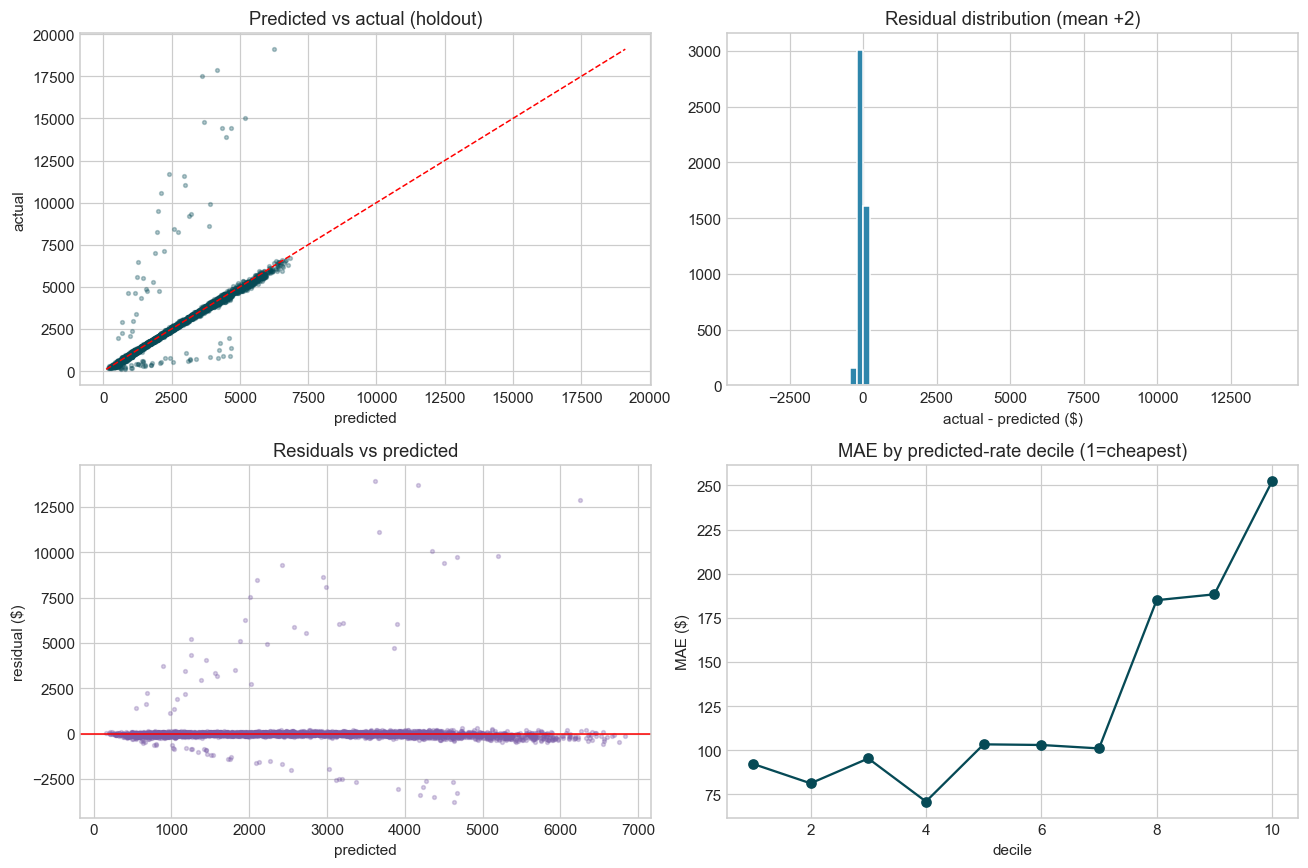

MAE by distance bucket:


,mean,count
bucket,,
"(0, 500]",96.1,1079
"(500, 1000]",80.0,1520
"(1000, 1500]",121.2,890
"(1500, 2000]",159.9,595
"(2000, 4000]",246.6,769


,load_id,pickup,delivery,distance,equipment,posted_rate,pred,abs_err
392,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,17514.1,3612.7,13901.4
3066,TR-046214,Columbia,Tucson,2023.4,Flatbed,17893.2,4170.3,13722.9
4151,TR-047299,Boston,Bakersfield,2979.1,Reefer,19110.3,6250.8,12859.5
3369,TR-046517,Toledo,Albuquerque,1684.3,Reefer,14784.4,3673.5,11110.9
3219,TR-046367,Bakersfield,Columbia,2251.9,Dry Van,14403.1,4351.3,10051.9
4389,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,15003.6,5199.2,9804.3
1120,TR-044268,Albany,Albuquerque,2492.6,Dry Van,14425.4,4666.7,9758.7
155,TR-043303,Atlanta,Phoenix,2083.1,Reefer,13894.6,4499.4,9395.2
237,TR-043385,Lexington,Lubbock,1187.0,Dry Van,11696.4,2418.4,9278.1
4439,TR-047587,Corpus Christi,Las Vegas,1383.3,Flatbed,11596.3,2947.3,8649.0


In [21]:
primary_results = results_full[~results_full["model"].str.startswith("Baseline")]
best_name = primary_results.iloc[0]["model"]
best_pred = holdout_preds[best_name]
resid = y_ho.to_numpy() - best_pred

print(f"Leading candidate on the pre-registered rule (lowest holdout MAE): {best_name}")
print(f"MAE={mean_absolute_error(y_ho, best_pred):.2f}  RMSE={np.sqrt(mean_squared_error(y_ho, best_pred)):.2f}  "
      f"R2={r2_score(y_ho, best_pred):.4f}  bias(mean residual)={resid.mean():+.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].scatter(best_pred, y_ho.to_numpy(), s=6, alpha=0.3, color="#064A56")
lo = min(best_pred.min(), y_ho.min()); hi = max(best_pred.max(), y_ho.max())
axes[0, 0].plot([lo, hi], [lo, hi], "--", color="red", lw=1)
axes[0, 0].set_title("Predicted vs actual (holdout)")
axes[0, 0].set_xlabel("predicted"); axes[0, 0].set_ylabel("actual")

axes[0, 1].hist(resid, bins=80, color="#2E86AB", edgecolor="white")
axes[0, 1].set_title(f"Residual distribution (mean {resid.mean():+.0f})")
axes[0, 1].set_xlabel("actual - predicted ($)")

axes[1, 0].scatter(best_pred, resid, s=6, alpha=0.3, color="#7B5EA7")
axes[1, 0].axhline(0, color="red", lw=1)
axes[1, 0].set_title("Residuals vs predicted")
axes[1, 0].set_xlabel("predicted"); axes[1, 0].set_ylabel("residual ($)")

decile = pd.qcut(best_pred, 10, labels=False, duplicates="drop")
mae_by_decile = pd.DataFrame({"decile": decile, "abs_err": np.abs(resid)}).groupby("decile")["abs_err"].mean()
axes[1, 1].plot(mae_by_decile.index + 1, mae_by_decile.values, marker="o", color="#064A56")
axes[1, 1].set_title("MAE by predicted-rate decile (1=cheapest)")
axes[1, 1].set_xlabel("decile"); axes[1, 1].set_ylabel("MAE ($)")
plt.tight_layout()
plt.show()

print("MAE by distance bucket:")
buckets = pd.cut(X_ho["distance"], [0, 500, 1000, 1500, 2000, 4000])
display(pd.DataFrame({"MAE": np.abs(resid), "bucket": buckets}).groupby("bucket", observed=True)["MAE"]
        .agg(["mean", "count"]).round(1))

worst = holdout.assign(pred=best_pred, abs_err=np.abs(resid)).nlargest(10, "abs_err")
display(worst[["load_id", "pickup", "delivery", "distance", "equipment", "posted_rate", "pred", "abs_err"]].round(1))

Residuals are centred near zero (no systematic over/under-pricing), with a heavy right tail: the largest absolute errors sit on the most expensive loads — expected, since those rows carry the most variance (RMSE ≫ MAE everywhere). Error grows with the predicted decile and is spread across distance buckets rather than concentrated in one segment, i.e. there is no single fixable slice left (e.g. no segment where the model collapses). This is the error profile we carry into selection.

## 12. Final Model Selection

The decision is made from the Section 10 table under the rule stated *before* the results were seen:

- **Primary:** lowest MAE on the October-2025 holdout among production-eligible models (full feature set).
- **Guards:** RMSE and R² must not be materially worse; the model must handle unseen cities via `handle_unknown="ignore"`, tolerate the December file's absent columns through the same imputer, and extrapolate calendar features into November/December (which lie beyond the training range).

In [22]:
winner = primary_results.iloc[0]
print("Production-eligible models, ranked by holdout MAE:")
display(primary_results.reset_index(drop=True).round(4))

print(f"\nSELECTED MODEL: {winner['model']}")
print(f"  MAE  = {winner['MAE']:.2f}   RMSE = {winner['RMSE']:.2f}   R2 = {winner['R2']:.4f}   {winner['detail']}")
margin = primary_results.iloc[1]["MAE"] - winner["MAE"]
print(f"  margin over runner-up: {margin:.2f} MAE ({margin / winner['MAE'] * 100:.1f}%)")

mean_mae = baseline_results.iloc[0]["MAE"]
rpm_mae = baseline_results.iloc[1]["MAE"]
print(f"  vs mean baseline   : {mean_mae:.1f} -> {winner['MAE']:.1f} MAE ({(1 - winner['MAE']/mean_mae)*100:.1f}% lower)")
print(f"  vs $/mile baseline : {rpm_mae:.1f} -> {winner['MAE']:.1f} MAE ({(1 - winner['MAE']/rpm_mae)*100:.1f}% lower)")

selected_name = winner["model"]
selected_num_cols = FEATURES

Production-eligible models, ranked by holdout MAE:


,model,MAE,RMSE,R2,fit_seconds,detail
0,"Ridge (alpha grid, TimeSeriesSplit)",127.3124,647.6294,0.8205,1.88,best alpha=10
1,ExtraTrees,131.4664,651.6646,0.8182,13.21,
2,RandomForest,137.8737,652.5912,0.8177,12.59,
3,HistGradientBoosting,152.4604,657.5286,0.8150,4.36,
4,XGBoost,335.1666,829.9875,0.7052,1.67,



SELECTED MODEL: Ridge (alpha grid, TimeSeriesSplit)
  MAE  = 127.31   RMSE = 647.63   R2 = 0.8205   best alpha=10
  margin over runner-up: 4.15 MAE (3.3%)
  vs mean baseline   : 1179.8 -> 127.3 MAE (89.2% lower)
  vs $/mile baseline : 253.8 -> 127.3 MAE (49.8% lower)


## 13. Final Training on All Labeled Data

The October holdout has served its purpose (model selection). The assessment requires predictions for **every** row of `validation.csv` and for December, so the selected pipeline is refit on **all 48,000 labeled rows** (January–October 2025). Refitting on the full data after a time-based selection step is standard: no information is lost, and the holdout rows now contribute to the final model instead of sitting idle. All preprocessing is refit together with the model, still via the pipeline.

In [23]:
from sklearn.base import clone

base_pipe, base_grid, _ = make_models()[selected_name]
final_model = Pipeline([("pre", clone(base_pipe.named_steps["pre"])),
                        ("model", clone(base_pipe.named_steps["model"]))])
t0 = time.time()
if base_grid:
    final_model = GridSearchCV(final_model, base_grid, cv=TimeSeriesSplit(3),
                               scoring="neg_mean_absolute_error", n_jobs=1)
final_model.fit(dev[FEATURES], dev["posted_rate"])
print(f"Final model: {selected_name}")
print(f"trained on all {len(dev):,} labeled rows "
      f"({dev['date'].min().date()} -> {dev['date'].max().date()}) in {time.time()-t0:.1f}s")
if isinstance(final_model, GridSearchCV):
    print("grid-selected params:", final_model.best_params_)

Final model: Ridge (alpha grid, TimeSeriesSplit)
trained on all 48,000 labeled rows (2025-01-01 -> 2025-10-31) in 2.8s
grid-selected params: {'model__alpha': 1}


## 14. Generate Validation Predictions

All 12,000 rows of `validation.csv`, ordered exactly as in `validation-predictions-template.csv`. Checks before writing: exact column names/order, exact row count, ID set and order identical to the template, no missing/duplicate IDs, finite numeric strictly positive rates.

In [24]:
val_feat = build_features(validation_df)
val_pred = final_model.predict(val_feat[selected_num_cols])

pred_by_id = pd.DataFrame({"load_id": validation_df["load_id"].astype(str),
                           "predicted_rate": val_pred})
submission = template_df[["load_id"]].copy()
submission["load_id"] = submission["load_id"].astype(str)
submission = submission.merge(pred_by_id, on="load_id", how="left")

assert list(submission.columns) == ["load_id", "predicted_rate"], submission.columns.tolist()
assert len(submission) == 12000, len(submission)
assert submission["predicted_rate"].notna().all()
assert submission["load_id"].is_unique
assert set(submission["load_id"]) == set(template_df["load_id"].astype(str))
assert np.isfinite(submission["predicted_rate"]).all()
assert (submission["predicted_rate"] > 0).all()

submission.to_csv(OUT_DIR / "validation_predictions.csv", index=False)
print("wrote validation_predictions.csv")
print("rows:", len(submission))
print("predicted_rate stats:")
display(submission["predicted_rate"].describe().round(2).to_frame().T)
print("target stats for reference (train):")
display(train_df["posted_rate"].describe().round(2).to_frame().T)
display(submission.head())

wrote validation_predictions.csv
rows: 12000
predicted_rate stats:


,count,mean,std,min,25%,50%,75%,max
predicted_rate,12000.0,2426.37,1371.94,195.01,1331.65,2082.14,3399.55,6889.18


target stats for reference (train):


,count,mean,std,min,25%,50%,75%,max
posted_rate,48000.0,2373.98,1486.49,57.22,1251.55,2030.76,3330.75,25533.0


,load_id,predicted_rate
0,TE-000001,897.628413
1,TE-000002,5020.730373
2,TE-000003,5291.971307
3,TE-000004,4115.616932
4,TE-000005,1862.813746


## 15. Generate December Predictions

The December input has only seven columns — no `market_index`, `quote_signal` or coordinates. The feature builder turns those into NaN, and the pipeline's imputer (fit on training data) handles them exactly like the missing cells seen during training. The original seven-column structure and order are preserved; only `predicted_rate` is filled. Saved as **`december_chart_inputs.csv`** (the scorer's expected name; the supplied input file stays untouched for reproducibility). The curve should vary smoothly with date - weekday effects plus a gentle drift, with no artificial jumps (consequence of the continuous week index chosen in Section 7).

In [25]:
dec_raw = pd.read_csv(ROOT / FILES["december"], parse_dates=["date"])
dec_feat = build_features(dec_raw)
dec_pred = final_model.predict(dec_feat[selected_num_cols])

dec_out = dec_raw.copy()
dec_out["predicted_rate"] = dec_pred

expected_cols = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
assert list(dec_out.columns) == expected_cols, dec_out.columns.tolist()
assert len(dec_out) == 31
assert dec_out["date"].dt.strftime("%Y-%m-%d").tolist() == [f"2025-12-{d:02d}" for d in range(1, 32)]
assert dec_out["pickup"].eq("Lexington").all()
assert dec_out["delivery"].eq("Fort Wayne").all()
assert np.allclose(dec_out["distance"], 360.0)
assert dec_out["equipment"].eq("Dry Van").all()
assert np.allclose(dec_out["weight"], 32000.0)
assert np.isfinite(dec_out["predicted_rate"]).all() and (dec_out["predicted_rate"] > 0).all()

dec_out.to_csv(OUT_DIR / "december_chart_inputs.csv", index=False)
print("wrote december_chart_inputs.csv (31 rows, predicted_rate filled)")
display(dec_out.head(4).round(2))
print("December prediction range: %.1f -> %.1f  (mean %.1f)"
      % (dec_out["predicted_rate"].min(), dec_out["predicted_rate"].max(), dec_out["predicted_rate"].mean()))

lex_fw = train_df[(train_df["pickup"] == "Lexington") & (train_df["delivery"] == "Fort Wayne")]
print("historical Lexington -> Fort Wayne rates (train): "
      f"n={len(lex_fw)}, mean={lex_fw['posted_rate'].mean():.1f}, "
      f"range=[{lex_fw['posted_rate'].min():.1f}, {lex_fw['posted_rate'].max():.1f}]")

wrote december_chart_inputs.csv (31 rows, predicted_rate filled)


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,979.21
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,975.07
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,977.01
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,972.88


December prediction range: 968.7 -> 1030.8  (mean 999.2)
historical Lexington -> Fort Wayne rates (train): n=32, mean=856.6, range=[757.9, 973.8]


## 16. Run Official Scorer

`score.py` is executed **unmodified** as instructed (`--predictions validation_predictions.csv --december-predictions december_chart_inputs.csv`). It validates both files and writes `scorer_results/candidate_december.png`, which is embedded below.

$ C:\Users\Mowleen\AppData\Local\Programs\Python\Python310\python.exe score.py --predictions validation_predictions.csv --december-predictions december_chart_inputs.csv
Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.

exit code: 0
chart exists: scorer_results\candidate_december.png (88,225 bytes)


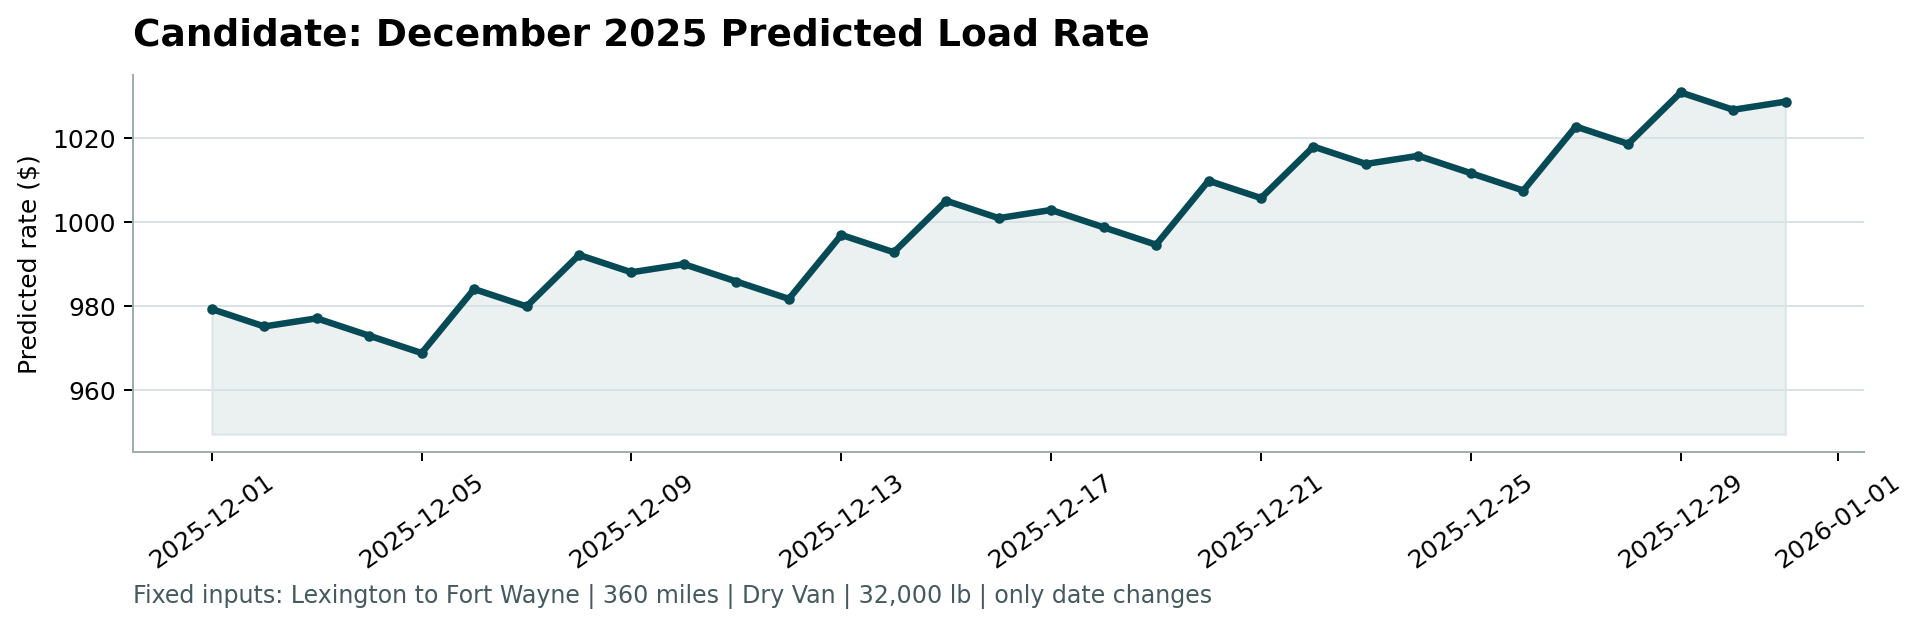

In [26]:
cmd = [sys.executable, "score.py",
       "--predictions", "validation_predictions.csv",
       "--december-predictions", "december_chart_inputs.csv"]
proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ROOT))
print("$ " + " ".join(cmd))
print(proc.stdout)
if proc.stderr.strip():
    print("stderr:\n" + proc.stderr)
print("exit code:", proc.returncode)
assert proc.returncode == 0, "scorer failed"

chart_path = ROOT / "scorer_results" / "candidate_december.png"
assert chart_path.is_file(), f"missing {chart_path}"
print("chart exists:", chart_path, f"({chart_path.stat().st_size:,} bytes)")
display(Image(filename=str(chart_path)))